# 05 - Benchmark de Modelos

Benchmark de cinco modelos de clasificación binaria con tracking
de experimentos via MLflow. Los modelos se evalúan sobre el mismo
test set con métricas apropiadas para datasets desbalanceados:
precision, recall y F1 por clase, priorizando F1 Macro como
métrica de selección.

Modelos evaluados, en orden de complejidad creciente:
Regresión Logística (baseline), Random Forest, XGBoost, LightGBM, SVM.

## Cómo usar este notebook

Para ver los experimentos en la UI de MLflow, una vez ejecutadas
todas las celdas corré este comando desde la carpeta notebooks/:

    mlflow ui --host 127.0.0.1 --port 5001 --backend-store-uri sqlite:///mlflow.db

Luego abrí http://127.0.0.1:5001 en el browser.

## 1. Carga de datos procesados

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow.sklearn
import mlflow
import joblib
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from mlflow.tracking import MlflowClient


X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (18093, 4)
X_test:  (4524, 4)
y_train: (18093,)
y_test:  (4524,)


## 2. MLflow Experiment Tracking

Cada entrenamiento se registra en MLflow con sus parámetros y métricas.
Esto permite comparar experimentos de forma sistemática y reproducible,
replicando el flujo de trabajo estándar en equipos de ML.


In [20]:
warnings.filterwarnings('ignore')

mlflow.set_tracking_uri("sqlite:///mlflow.db")

client = MlflowClient()
experiment = client.get_experiment_by_name("asteroid-hazard-classifier")
if experiment is None:
    experiment_id = client.create_experiment("asteroid-hazard-classifier")
else:
    experiment_id = experiment.experiment_id

def evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test):
    with mlflow.start_run(run_name=nombre, experiment_id=experiment_id):
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        
        reporte = classification_report(y_test, y_pred,
                                       target_names=['No peligroso', 'Peligroso'],
                                       output_dict=True)
        
        mlflow.log_param("modelo", nombre)
        mlflow.log_metric("precision_peligroso", reporte['Peligroso']['precision'])
        mlflow.log_metric("recall_peligroso", reporte['Peligroso']['recall'])
        mlflow.log_metric("f1_peligroso", reporte['Peligroso']['f1-score'])
        mlflow.log_metric("f1_macro", reporte['macro avg']['f1-score'])
        mlflow.sklearn.log_model(modelo, nombre)
        
        print(f"\n=== {nombre} ===")
        print(classification_report(y_test, y_pred,
                                    target_names=['No peligroso', 'Peligroso']))
    return y_pred

print(f"Experimento ID: {experiment_id}")

Experimento ID: 1


## 3. Entrenamiento y evaluación de modelos

In [21]:
scale_pos_weight = y_train.value_counts()[False] / y_train.value_counts()[True]

modelos = {
    "Regresion Logistica": LogisticRegression(
        class_weight='balanced', random_state=42, max_iter=1000
    ),
    "Random Forest": RandomForestClassifier(
        class_weight='balanced', random_state=42, n_estimators=100
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'
    ),
    "LightGBM": LGBMClassifier(
        class_weight='balanced', random_state=42, verbose=-1
    ),
    "SVM": SVC(
        class_weight='balanced', random_state=42, probability=True
    )
}

resultados = {}
for nombre, modelo in modelos.items():
    y_pred = evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test)
    resultados[nombre] = y_pred

2026/04/25 13:41:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/25 13:41:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== Regresion Logistica ===
              precision    recall  f1-score   support

No peligroso       1.00      0.87      0.93      4272
   Peligroso       0.31      0.97      0.47       252

    accuracy                           0.88      4524
   macro avg       0.65      0.92      0.70      4524
weighted avg       0.96      0.88      0.90      4524



2026/04/25 13:41:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/25 13:41:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/25 13:41:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/25 13:41:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p


=== Random Forest ===
              precision    recall  f1-score   support

No peligroso       0.96      0.99      0.98      4272
   Peligroso       0.63      0.38      0.48       252

    accuracy                           0.95      4524
   macro avg       0.80      0.69      0.73      4524
weighted avg       0.95      0.95      0.95      4524


=== XGBoost ===
              precision    recall  f1-score   support

No peligroso       0.99      0.93      0.96      4272
   Peligroso       0.41      0.80      0.55       252

    accuracy                           0.93      4524
   macro avg       0.70      0.87      0.75      4524
weighted avg       0.96      0.93      0.94      4524



2026/04/25 13:41:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/25 13:41:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== LightGBM ===
              precision    recall  f1-score   support

No peligroso       0.99      0.91      0.95      4272
   Peligroso       0.38      0.92      0.54       252

    accuracy                           0.91      4524
   macro avg       0.69      0.92      0.74      4524
weighted avg       0.96      0.91      0.93      4524



2026/04/25 13:41:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/25 13:41:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== SVM ===
              precision    recall  f1-score   support

No peligroso       1.00      0.87      0.93      4272
   Peligroso       0.31      1.00      0.47       252

    accuracy                           0.87      4524
   macro avg       0.65      0.93      0.70      4524
weighted avg       0.96      0.87      0.90      4524



## 4. Comparativa de modelos

In [22]:
resumen = []
for nombre, y_pred in resultados.items():
    resumen.append({
        'Modelo': nombre,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Peligroso': f1_score(y_test, y_pred),
        'F1 Macro': f1_score(y_test, y_pred, average='macro')
    })

df_resultados = pd.DataFrame(resumen)
df_resultados = df_resultados.sort_values('F1 Macro', ascending=False)
print(df_resultados.round(3).to_string(index=False))

             Modelo  Precision  Recall  F1 Peligroso  F1 Macro
            XGBoost      0.414   0.798         0.545     0.753
           LightGBM      0.377   0.921         0.535     0.743
      Random Forest      0.634   0.385         0.479     0.727
                SVM      0.306   0.996         0.468     0.698
Regresion Logistica      0.306   0.972         0.466     0.698


In [23]:
print("MLflow version:", mlflow.__version__)
print("Tracking URI:", mlflow.get_tracking_uri())

# Listar todos los experimentos
client = mlflow.tracking.MlflowClient()
experiments = client.search_experiments()
for exp in experiments:
    print(f"\nExperimento: {exp.name} (ID: {exp.experiment_id})")
    runs = client.search_runs(exp.experiment_id)
    print(f"Runs: {len(runs)}")
    for run in runs:
        print(f"  - {run.info.run_name}: {run.data.metrics}")
        

MLflow version: 3.11.1
Tracking URI: sqlite:///mlflow.db

Experimento: asteroid-hazard-classifier (ID: 1)
Runs: 10
  - SVM: {'precision_peligroso': 0.30572472594397077, 'recall_peligroso': 0.996031746031746, 'f1_peligroso': 0.4678471575023299, 'f1_macro': 0.6981242057104126}
  - LightGBM: {'precision_peligroso': 0.3772357723577236, 'recall_peligroso': 0.9206349206349206, 'f1_peligroso': 0.5351787773933102, 'f1_macro': 0.7429591478947972}
  - XGBoost: {'precision_peligroso': 0.4144329896907217, 'recall_peligroso': 0.7976190476190477, 'f1_peligroso': 0.5454545454545454, 'f1_macro': 0.7525732599730914}
  - Random Forest: {'precision_peligroso': 0.6339869281045751, 'recall_peligroso': 0.38492063492063494, 'f1_peligroso': 0.47901234567901235, 'f1_macro': 0.7272997630280981}
  - Regresion Logistica: {'precision_peligroso': 0.30625, 'recall_peligroso': 0.9722222222222222, 'f1_peligroso': 0.46577946768060835, 'f1_macro': 0.6977471625546614}
  - SVM: {'precision_peligroso': 0.30450669914738127,

## 5. Matriz de confusión — XGBoost

XGBoost fue seleccionado como modelo principal por F1 Macro 0.753,
el más alto del benchmark. La matriz de confusión desagrega los
resultados en verdaderos positivos, falsos positivos, verdaderos
negativos y falsos negativos, permitiendo evaluar el comportamiento
del modelo en cada clase por separado.

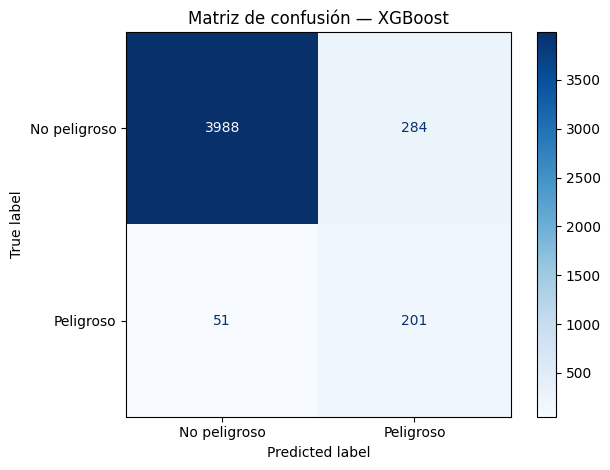

In [24]:
cm = confusion_matrix(y_test, resultados['XGBoost'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No peligroso', 'Peligroso'])
disp.plot(cmap='Blues')
plt.title('Matriz de confusión — XGBoost')
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning — GridSearchCV

Búsqueda exhaustiva sobre 27 combinaciones de hiperparámetros con
validación cruzada de 5 folds. GridSearchCV garantiza que la
selección de hiperparámetros no depende de un split particular
del dataset.

In [25]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'scale_pos_weight': [scale_pos_weight]
}

xgb_tuning = XGBClassifier(random_state=42, eval_metric='logloss')

grid_search = GridSearchCV(
    xgb_tuning,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid_search.best_params_)
print(f"\nMejor F1 Macro en cross-validation: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores parámetros:
{'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 200, 'scale_pos_weight': np.float64(16.949404761904763)}

Mejor F1 Macro en cross-validation: 0.7454


## 7. Evaluación del modelo tuneado

In [26]:
xgb_final = XGBClassifier(
    learning_rate=0.3,
    max_depth=7,
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_final.fit(X_train, y_train)
y_pred_final = xgb_final.predict(X_test)

print("XGBoost Tuneado")
print(classification_report(y_test, y_pred_final,
                            target_names=['No peligroso', 'Peligroso']))

XGBoost Tuneado
              precision    recall  f1-score   support

No peligroso       0.98      0.94      0.96      4272
   Peligroso       0.42      0.73      0.54       252

    accuracy                           0.93      4524
   macro avg       0.70      0.84      0.75      4524
weighted avg       0.95      0.93      0.94      4524



GridSearchCV no mejoró el modelo base en F1 Macro (0.75 vs 0.75).
El tuning bayesiano con Optuna se evalúa en 07_optuna.ipynb como
alternativa más eficiente para explorar el espacio de hiperparámetros.

In [27]:
import joblib
joblib.dump({'modelo': modelos['XGBoost'], 'umbral': 0.20}, '../data/xgboost_final.pkl')
print("Modelo guardado en data/xgboost_final.pkl")

Modelo guardado en data/xgboost_final.pkl
